# Predicting State-wise EV Adoption
## Notebook 05: Model Building

### Purpose
This notebook focuses on preparing the data and training machine learning models to predict EV adoption. 
We will handle feature selection by dropping redundant and leaky features discovered during the EDA, properly encode our categorical variables, and train two robust tree-based models: a **Random Forest Regressor** and an **XGBoost Regressor**.

In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pickle
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading the featured dataset
df = pd.read_csv('../Data/ev_adoption_featured.csv')
df.head()

,country,region,year,year_normalized,vehicle_segment,ev_sales(units),petrol_car_sales(units),diesel_car_sales(units),ice_total_sales(units),total_vehicle_sales(units),...,co2_emissions(mt),ev_subsidy(usd),emission_regulation(scale_0-100),ev_growth_rate_yoy(%),ev_growth_rate_category,ev_domination(0/1),economic_index,policy_index,policy_index_lagged_1y,environmental_stringency_ratio
0,Australia,Oceania,2010,0,commercial,5,92877,61921,154798,154803,...,88.7,0,30.4,0.00,Decline,0,4615.5576,0.0,0.0,2.824841
1,Australia,Oceania,2010,0,mass_market,57,535933,73089,609022,609079,...,88.7,0,30.4,0.00,Decline,0,4615.5576,0.0,0.0,2.824841
2,Australia,Oceania,2010,0,premium,37,235282,20462,255744,255781,...,88.7,0,30.4,0.00,Decline,0,4615.5576,0.0,0.0,2.824841
3,Australia,Oceania,2011,1,commercial,11,98092,65395,163487,163498,...,88.3,0,30.8,120.00,Extraordinary Growth,0,4694.5423,0.0,0.0,2.776730
4,Australia,Oceania,2011,1,mass_market,129,569679,77684,647363,647492,...,88.3,0,30.8,126.32,Extraordinary Growth,0,4694.5423,0.0,0.0,2.776730


In [4]:
# 1. Dropping features that cause Data Leakage and Multicollinearity
leakage_cols = ['market_share_change(%)', 'ev_growth_rate_yoy(%)', 'ev_growth_rate_category', 'ev_domination(0/1)', 'ev_sales(units)', 'chargers_per_ev_ratio']
collinear_cols = ['ice_total_sales(units)', 'total_vehicle_sales(units)', 'ev_ice_ratio']
components_cols = ['gdp(usd/person)', 'urban_population(%)', 'co2_emissions(mt)', 'ev_subsidy(usd)', 'emission_regulation(scale_0-100)']
redundant_cols = ['year'] # keeping year_normalized

cols_to_drop = leakage_cols + collinear_cols + components_cols + redundant_cols
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

Original shape: (1200, 32)
Cleaned shape: (1200, 17)


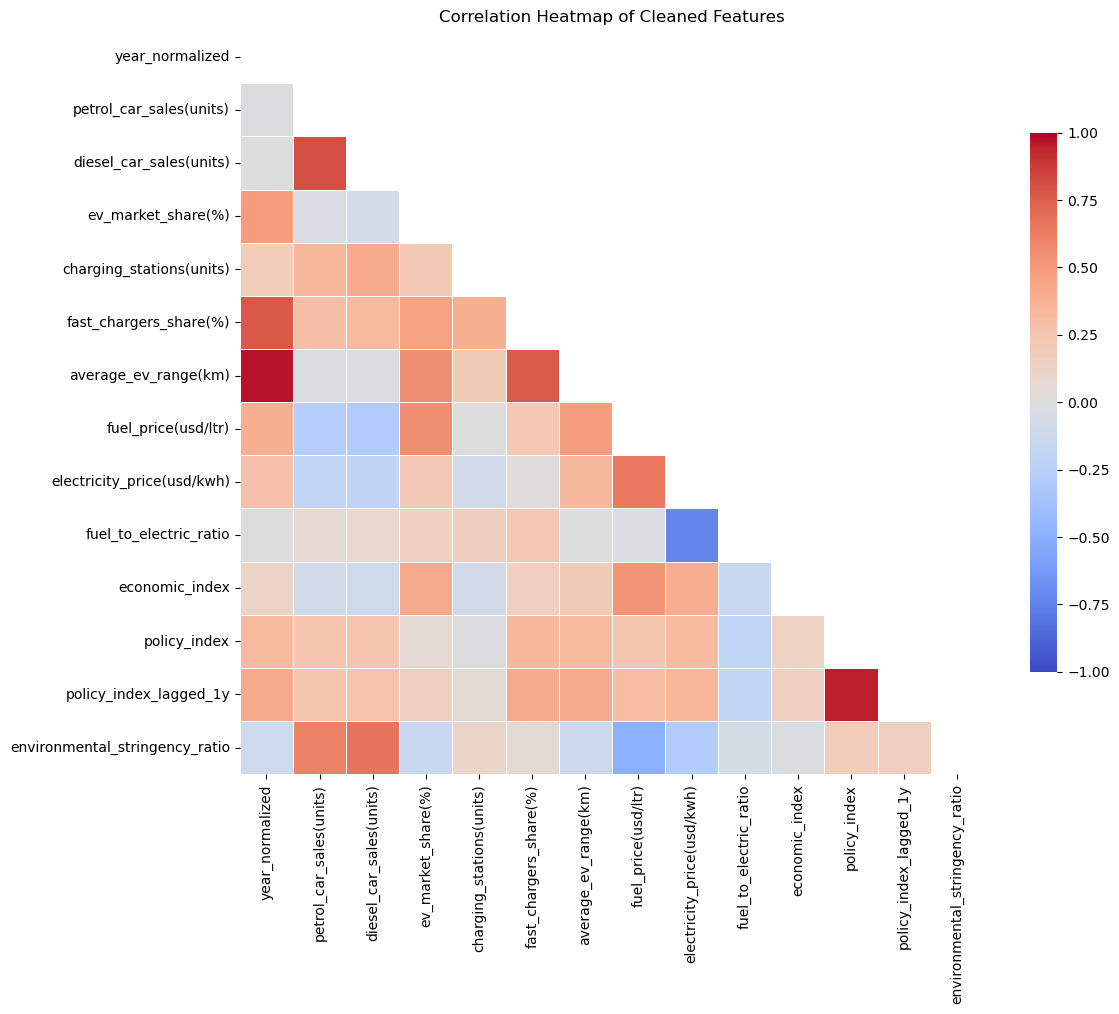

In [5]:
# Visualizing the correlation heatmap of the cleaned numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 10))

# Calculate correlation matrix using only numeric columns
corr_cleaned = df_cleaned.select_dtypes(include=[np.number]).corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_cleaned, dtype=bool))

# Draw the heatmap
sns.heatmap(corr_cleaned, mask=mask, cmap='coolwarm', vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .7})
plt.title('Correlation Heatmap of Cleaned Features')
plt.show()

In [6]:
# 2. Defining features (X) and target (y)
X = df_cleaned.drop(columns=['ev_market_share(%)'])
y = df_cleaned['ev_market_share(%)']

# Splitting data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# 3. Creating a Preprocessing Pipeline
# Tree models handle numerical outliers natively, so we only need to encode our categorical text data.
categorical_features = ['country', 'region', 'vehicle_segment']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Leave all numerical features exactly as they are
)

In [8]:
# 4. Initializing and training Model 1: Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
print("Random Forest Training Complete!")

Training Random Forest...
Random Forest Training Complete!


In [9]:
# 5. Initializing and training Model 2: XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1))
])

print("Training XGBoost...")
xgb_pipeline.fit(X_train, y_train)
print("XGBoost Training Complete!")

Training XGBoost...
XGBoost Training Complete!


In [10]:
# 6. Saving Models and Test Data for Evaluation
with open('../Models/rf_model.pkl', 'wb') as f:
     pickle.dump(rf_pipeline, f)
    
with open('../Models/xgb_model.pkl', 'wb') as f:
     pickle.dump(xgb_pipeline, f)

X_test.to_csv('../Data/X_test.csv', index=False)
y_test.to_csv('../Data/y_test.csv', index=False)
print("Models and Test data saved successfully to disk.")

Models and Test data saved successfully to disk.


### Observation Summary: 

In this notebook, we took our deeply analyzed data and built a professional Machine Learning architecture. Here is exactly what we did, step-by-step:

#### **Step 1: Cleaning the Data (Removing "Cheats" and Clutter)**
We started by dropping columns that would ruin our model. 
- **We removed "Data Leaks"** (like `chargers_per_ev_ratio` and `ev_sales`), which act like an answer key and let the model cheat in predicting Market Share.
- **We removed "Clutter"** (like redundant GDP and Subsidy metrics) to ensure our model purely focuses on the clean, powerful indices we created.

#### **Step 2: Splitting the Data**
We split our dataset into two parts:
- **Training Data (80%)**: The flashcards the model uses to learn the basic rules of EV adoption over thousands of examples.
- **Testing Data (20%)**: The final exam we completely hid from the model to test if it actually learned, or if it just memorized the flashcards!

#### **Step 3: Translating Text for the Computer**
Machine Learning models only understand numbers. We built an automated pipeline using a **ColumnTransformer** to instantly translate text columns like `country` and `vehicle_segment` into 1s and 0s (a process called One-Hot Encoding).

#### **Step 4: Training the Models**
Instead of basic Linear Regression, we deployed two highly advanced **Tree-Based Models**. Tree models are perfect for this dataset because they don't get confused by massive outliers (like China's millions of charging stations) or extreme skewness in the EV space. 

Here is a simple breakdown of the two model architectures we used:

**1. Random Forest Regressor (The Committee)**
- **How it works:** Imagine asking 100 different EV experts to predict the market share of a country, and then simply taking the exact average of all their guesses. Random Forest builds 100 different "Decision Trees" on random chunks of data to get varied opinions.
- **Why we use it:** It is incredibly stable and almost never "overfits" (memorizes the data). By averaging 100 trees, it smooths out wild, incorrect errors and provides a very reliable, sturdy baseline prediction.

**2. XGBoost Regressor (The Perfectionist)**
- **How it works:** Instead of building 100 trees at the same time and averaging them, XGBoost builds *one single tree at a time*. After the first tree makes a guess, XGBoost looks at exactly where that tree messed up. It then builds a second tree specifically designed to fix the first tree's mistakes. It repeats this obsessive correction process 100 times.
- **Why we use it:** It is famously one of the most powerful algorithms in modern tabular Machine Learning. By fixing its own errors step-by-step, it almost always achieves vastly higher accuracy than a generic Random Forest approach.

#### **Next Steps**
Both trained models and the unseen "Testing Data" have been saved directly to the `Models/` folder. 
Proceed to Notebook 06: Model Evaluation